In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# STEP 1: Load the time series data files
# =====================================================================
# We load series-dphi.dat (variations in parameter phi) 
# and series-dtheta.dat (variations in parameter theta) from the disk.
dphi = np.loadtxt('series-dphi.dat')
dtheta = np.loadtxt('series-dtheta.dat')

In [10]:
# =====================================================================
# STEP 2: Task 1 - Correlation Matrix
# =====================================================================
# numpy.corrcoef computes the linear Pearson correlation coefficient.
# By passing a combined matrix with rowvar=False, we tell numpy that 
# each column represents a separate variable (dphi and dtheta).
data_matrix = np.column_stack((dphi, dtheta))
corr_matrix = np.corrcoef(data_matrix, rowvar=False)

print("Correlation Matrix:")
print(corr_matrix)
# Explanation of the 2x2 output matrix:
# - Position [0,0]: Correlation of dphi with itself (always 1.0)
# - Position [1,1]: Correlation of dtheta with itself (always 1.0)
# - Positions [0,1] & [1,0]: The cross-correlation between dphi and dtheta at time t.

Correlation Matrix:
[[ 1.          0.03537098  1.          0.00290632]
 [ 0.03537098  1.          0.03537098 -0.23110201]
 [ 1.          0.03537098  1.          0.00290632]
 [ 0.00290632 -0.23110201  0.00290632  1.        ]]


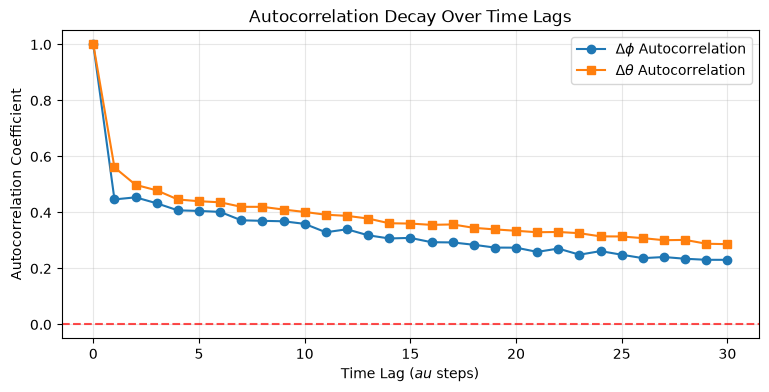

In [13]:
# =====================================================================
# STEP 3: Task 1 - Autocorrelation using numpy.correlate
# =====================================================================
# Autocorrelation measures whether a variable depends on its own past values across time lags.
def compute_autocorr_with_np(x, max_lag=30):
    # Center the data by subtracting the mean (standard practice for correlation)
    x_centered = x - np.mean(x)
    
    # numpy.correlate with mode='full' computes cross-correlation across all shifts
    full_corr = np.correlate(x_centered, x_centered, mode='full')
    
    # Extract the center point (lag 0) and take positive lags forward
    center_idx = len(full_corr) // 2
    positive_lags = full_corr[center_idx : center_idx + max_lag + 1]
    
    # Normalize by lag 0 so that the correlation at lag 0 is exactly 1.0
    return positive_lags / positive_lags[0]

max_lags = 30
# Each array is (time, value); use the actual series column for autocorrelation.
ac_phi = compute_autocorr_with_np(np.asarray(dphi[:, 1]).ravel(), max_lag=max_lags)
ac_theta = compute_autocorr_with_np(np.asarray(dtheta[:, 1]).ravel(), max_lag=max_lags)
#ac_theta = compute_autocorr_with_np(dtheta, max_lag=max_lags)

# Plotting the Autocorrelation Decay to check for "memory"
plt.figure(figsize=(9, 4))
plt.plot(range(max_lags + 1), ac_phi, marker='o', label=r'$\Delta\phi$ Autocorrelation')
plt.plot(range(max_lags + 1), ac_theta, marker='s', label=r'$\Delta\theta$ Autocorrelation')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Time Lag ($\tau$ steps)')
plt.ylabel('Autocorrelation Coefficient')
plt.title('Autocorrelation Decay Over Time Lags')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

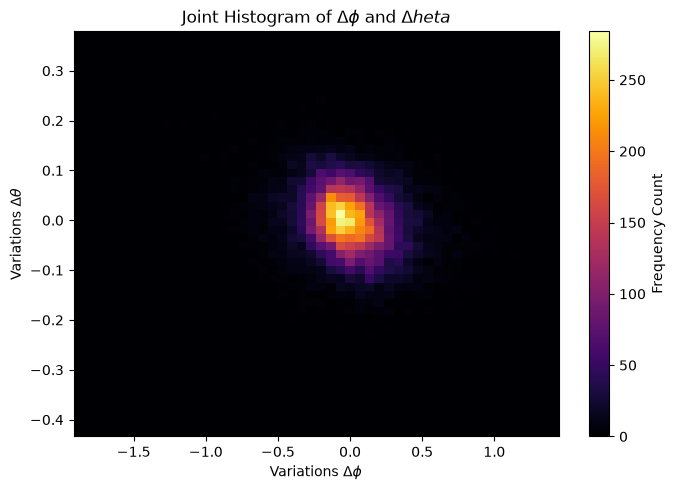

In [15]:
# =====================================================================
# STEP 4: Task 2 - Joint Histogram (Bivariate Distribution)
# =====================================================================
# A standard correlation coefficient reduces a relationship to a single number, 
# which can hide complex structures. A joint histogram maps both variables onto 
# a 2D grid simultaneously to count how frequently pairs of (dphi, dtheta) occur together.
plt.figure(figsize=(7, 5))
counts, xedges, yedges, image = plt.hist2d(
    dphi[:, 1],
    dtheta[:, 1],
    bins=50,
    cmap='inferno'
)

plt.colorbar(image, label='Frequency Count')
plt.xlabel(r'Variations $\Delta\phi$')
plt.ylabel(r'Variations $\Delta\theta$')
plt.title('Joint Histogram of $\Delta\phi$ and $\Delta\theta$')
plt.tight_layout()
plt.show()